# **COMMODITY-ASSET PRICING**
## ECON 323 | GROUP 3 & GROUP 4

*MEMBERS*
- Yashas Ganesh Prasad
- Taha Memon
- Jasper Yang
- Xuanfu Zhu
- Syed Zaim Naqvi

*TABLE OF CONTENTS*
- Introduction
- Data Ingestion
- Data Cleaning & Overview
- Data Visualization
- Data Modelling & Methodology
- Summary of Results
- Conclusion
- Sources

# **1. INTRODUCTION**

Gold has long played a dual role in the global financial system as both a commodity and a monetary asset with huge economic value (World Gold Council, 2025), distinguishing it from traditional financial securities such as equities and fixed-income instruments. **Unlike stocks or bonds, gold does not generate cash flows (Jaffer, 2024), and its valuation is therefore not based on discounted future earnings**. Instead, gold prices are primarily driven by **macroeconomic fundamentals (like inflation, unemployment, and overall GDP-per-capita growth), financial market conditions, and investor sentiment** (J.P. Morgan, 2025; World Gold Council, 2025). This distinctive characteristic has made gold a focal point in financial economics, particularly in **discussions surrounding portfolio diversification, inflation hedging, and safe-haven behaviour**.

A core finding in the literature is that the real interest rates (interest rates after taking into account inflation) are the primary driver of gold prices. Higher real yields increase the opportunity cost of holding gold, placing downward pressure on its price, while lower or negative real rates tend to support higher gold prices. Closely related is inflation expectations, which influence real rates and shape gold's role as a hedge against declining purchasing power.(Bampinas & Panagiotidis, 2015).

**Why is Gold considered a safe-haven asset?** Gold has consistently been used by investors to seek refuge from inflation, market crisis and market uncertainty. This is because **Gold provides economic stability**. Gold has served as a reliable store of wealth, consistently maintaining its value across historical periods, unlike fiat (paper) currencies, which tend to lose value due to inflation. Gold's intrinsic value has proven to remain stable across history. Due to this, **gold is commonly used as a hedge against inflation**, which helps preserve the real value of the assets of investors. Furthermore, **Gold offers investors a way to mitigate risk through diversification**, especially as gold prices tend to have a low correlation with other financial assets like equities (The Royal Mint. n.d.).

The traditional safe-haven hypothesis suggests that **gold should exhibit a negative relationship with risky assets, such as equities**, and a positive relationship with measures of uncertainty, such as market volatility. This has often been supported by empirical evidence, even during economic recessions, such as the Global Financial Crisis in 2008, when gold prices increased despite declines in equity markets (Baur & McDermott, 2010). 

However, the economic environment following the COVID-19 pandemic has raised questions about the stability of the relationship posited by the safe-haven hypothesis (Li, 2020). The unprecedented monetary expansion during the COVID-19 pandemic and the transition to **monetary tightening beginning on March 16, 2022 (li, 2023), combined with elevated inflation and heightened market volatility, have caused gold prices to deviate from their expected role as a traditional safe-haven asset**. In particular, periods of simultaneous declines in both equity markets and gold prices, along with stronger sensitivity to interest rate movements, suggest a potential shift in gold's role within financial markets.

This has led to the emergence of the Broken Safe-Haven hypothesis (Faraj et al., 2025), which argues that gold's ability to hedge against market risk may have weakened in the post-COVID-19 period. 

To examine this hypothesis, this study adopts a multivariate empirical framework incorporating key macroeconomic and financial variables. Given the potential for multicollinearity among these variables, the analysis uses **LASSO regression, OLS analysis and XGBoost Machine Learning** to assess whether gold continues to function as a safe-haven asset in the post-COVID-19 period.

**Research Question**

Using an empirical framework, does the safe-haven hypothesis for gold prices hold in the post-COVID-19 period, or is there evidence of a structural weakening in its safe-haven properties consistent with a "broken safe-haven" dynamic?



# **2. DATA INGESTION**

The dataset used in this study is constructed from a combination of sources to ensure both data availability and reliability across the key variables. The primary gold price data is obtained from a dataset hosted on Kaggle, which provides a comprehensive dataset on historical gold price series in a structured and readable format. This dataset serves as the dependent variable in the analysis.

The explanatory variables, covering macroeconomic and financial indicators, are sourced from the Federal Reserve Economic Data (FRED), and Yahoo Finance. These platforms are widely used in empirical finance research due to their high-frequency, reliable, and continuously updated data.

A key advantage of using FRED and Yahoo Finance is the ability to directly import data (via APIs). This eliminates the need for manual downloading and the updating of datasets, ensuring reproducibility, efficiency, and consistency in the data collection process.

By integrating data from these sources, the final dataset captures a comprehensive set of variables necessary to analyze gold price dynamics within a multivariate empirical framework.


In [ ]:
#installing required libraries
!pip install pandas
!pip install fredapi
!pip install yfinance

In [2]:
import pandas as pd

gold_data = pd.read_csv("../../data/Gold-Silver-GeopoliticalRisk_HistoricalData.csv") #allows import of locally downloaded dataset
gold_data['DATE'] = pd.to_datetime(gold_data['DATE']) #changes the data type of the column "DATE" to date-time
gold_data.set_index('DATE', inplace=True) #sets DATE as the index of the dataframe
gold_data = gold_data[gold_data.index >= '1999-01-01'] #filters the data to only get data after January 1st 1999
gold_data

,GOLD_PRICE,GOLD_OPEN,GOLD_HIGH,GOLD_LOW,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
DATE,,,,,,,,,,,,,,
2025-09-10,3630.90,3633.61,3634.42,3620.90,-0.07,40.92,40.89,40.94,40.72,0.09,NaN,NaN,NaN,NaN
2025-09-09,3633.61,3637.10,3674.75,3625.33,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN
2025-09-08,3635.84,3586.82,3646.60,3579.67,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN
2025-09-07,3591.19,3592.07,3596.56,3586.95,0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111.00,92.59,NaN
2025-09-05,3586.81,3547.00,3600.33,3540.05,1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999-01-08,291.25,291.05,291.25,291.25,-0.10,5.29,5.22,5.29,5.28,0.76,70.81,61.38,92.16,NaN
1999-01-07,291.55,288.25,291.55,291.55,1.32,5.25,5.16,5.25,5.23,1.55,68.03,64.87,59.03,NaN
1999-01-06,287.75,287.00,287.75,287.75,0.28,5.17,5.03,5.17,5.15,2.58,62.19,71.79,43.55,NaN


In [3]:
from fredapi import Fred

fred = Fred(api_key="77607617679b9e388bc1c17f17bf0874")

end = '2025-09-10'
start = '1991-01-01'

# this involves forming a dataframe of various variables imported from the FRED database, using date as the index
# using a specific observation_start and observation_end argument ensures that data is within the required dates
df1 = pd.DataFrame({
'interest_rate' : fred.get_series('REAINTRATREARAT10Y', observation_start = start, observation_end = end), 
'inflation_rate' : fred.get_series('FPCPITOTLZGUSA', observation_start = start, observation_end = end),
'expected_inflation' : fred.get_series('EXPINF10YR', observation_start = start, observation_end = end),
'gdp' : fred.get_series('GDP', observation_start = start, observation_end = end),
'10_year_treasury_note_yield' : fred.get_series('DGS10', observation_start = start, observation_end = end),
'wti_crude_oil_price' : fred.get_series('POILWTIUSDM', observation_start = start, observation_end = end)})

In [4]:
import yfinance as yf
# this involves importing data for various variables from Yahoo Finance directly
# by specifying the start and end arguments, the data will be within the required dates
gold_futures = yf.download('MGC=F', start=start, end=end)
vix = yf.download('^VIX', start=start, end=end)
us_dollar = yf.download('DX-Y.NYB', start=start, end=end)
s_and_p_500 = yf.download('^GSPC', start=start, end=end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
# merging all separate variables into one dataframe, using a column-wise concatenation
raw_data = pd.concat([df1, s_and_p_500, vix, us_dollar, gold_futures, gold_data], axis=1)
raw_data

/var/folders/rj/hc50s0817s95cntbt82680v80000gn/T/ipykernel_17108/1955241977.py:2: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  raw_data = pd.concat([df1, s_and_p_500, vix, us_dollar, gold_futures, gold_data], axis=1)


,interest_rate,inflation_rate,expected_inflation,gdp,10_year_treasury_note_yield,wti_crude_oil_price,"(Close, ^GSPC)","(High, ^GSPC)","(Low, ^GSPC)","(Open, ^GSPC)",...,GOLD_CHANGE_%,SILVER_PRICE,SILVER_OPEN,SILVER_HIGH,SILVER_LOW,SILVER_CHANGE_%,GPRD,GPRD_ACT,GPRD_THREAT,EVENT
1991-01-01,3.922931,4.234964,3.804597,6035.178,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-02,NaN,NaN,NaN,NaN,7.97,NaN,326.450012,330.750000,326.450012,330.200012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-03,NaN,NaN,NaN,NaN,7.93,NaN,321.910004,326.529999,321.899994,326.459991,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-04,NaN,NaN,NaN,NaN,8.02,NaN,321.000000,322.350006,318.869995,321.910004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-07,NaN,NaN,NaN,NaN,8.13,NaN,315.440002,320.970001,315.440002,320.970001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-05,NaN,NaN,NaN,NaN,4.10,NaN,6481.500000,6532.649902,6443.979980,6529.080078,...,1.15,41.01,40.69,41.44,40.55,0.76,166.42,110.61,224.05,NaN
2025-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.12,40.86,41.00,41.01,40.76,-0.34,83.51,111.00,92.59,NaN
2025-09-08,NaN,NaN,NaN,NaN,4.05,NaN,6495.149902,6508.669922,6483.290039,6498.089844,...,1.24,41.36,41.01,41.68,40.51,1.20,117.26,97.42,146.26,NaN
2025-09-09,NaN,NaN,NaN,NaN,4.08,NaN,6512.609863,6518.229980,6483.080078,6503.330078,...,-0.06,40.89,41.34,41.50,40.77,-1.13,NaN,NaN,NaN,NaN


In [6]:
#exporting merged dataframe as a csv file
raw_data.to_csv("../../data/raw_data.csv", index=True)

# **3. DATA CLEANING and OVERVIEW**



Two datasets will be used for our analysis. We will use both daily and weekly aggregated market data. While daily data will contain more observations and variation, market variables are often volatile and noisy on a daily basis so we have also constructed an aggregated weekly version to use in our models.

To ensure our regression results aren't "spurious," we transform raw prices into Log-Returns, which achieves stationarity. We also generate the Interaction Terms necessary to test the "Broken-Haven" hypothesis, specifically looking at how gold's relationship with the VIX changed after March 16th, 2022.

We've also constructed lagged variables to identify autoregressive relationship since commodity demand is often reactive to market conditions.


In [7]:
##### import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

# loading the raw ingested data
# using index_col=0 as the date is the first unnamed column in raw_data.csv
df = pd.read_csv('../../data/raw_data.csv', index_col=0, parse_dates=True)
df.index.name = 'DATE'

# sorting the index to ensure Time-Series logic works correctly
df.sort_index(inplace=True)
df.index = pd.to_datetime(df.index)

# standardizing column names by removing special characters
df.columns = [
    col.replace("('", "").replace("', '", "_").replace("')", "")
    .replace("^", "").replace("-", "_").replace(".", "_").replace("=", "_")
    for col in df.columns
]

# dropping columns that are completely empty to prevent data loss
df.dropna(axis=1, how='all', inplace=True)

# forward filling missing daily gaps in monthly/quarterly macro data
df.ffill(inplace=True)

# calculating Log-Returns for stationarity
# formula: ln(Price_t) - ln(Price_t-1)
df['gold_ret'] = np.log(df['Close_MGC_F']).diff()
df['silver_ret'] = np.log(df['SILVER_PRICE']).diff()
df['sp500_ret'] = np.log(df['Close_GSPC']).diff()

# defining structural break dummies for the analysis
# this marks the post-pandemic period starting in 2022
df['is_PostCovid'] = (df.index >= '2022-03-16').astype(int)

# 1-Day Return Lag
df['gold_ret_lag'] = df['gold_ret'].shift(1)
df['sp500_ret_lag'] = df['sp500_ret'].shift(1)
df['silver_ret_lag'] = df['silver_ret'].shift(1)

# 5-Day Volatility Lag (Rolling standard deviation of the last 5 days)
df['gold_vol_lag'] = df['gold_ret'].rolling(window=5).std().shift(1)

# 1-Day Lag Market Prices
df['wti_crude_oil_lag'] = df['wti_crude_oil_price'].shift(1)
df['Close_DX_Y_NYB_lag'] = df['Close_DX_Y_NYB'].shift(1)
df['Close_VIX_lag'] = df['Close_VIX'].shift(1)
df['interest_rate_lag'] = df['interest_rate'].shift(1)
df['expected_inflation_lag'] = df['expected_inflation'].shift(1)

# creating interaction terms (VIX x Post-Covid) to test the structural shift
df['VIX_x_PostCovid'] = df['Close_VIX_lag'] * df['is_PostCovid']

# removing NaNs created by the diff and lag functions
df.dropna(inplace=True)

# load GPR directly from source and merge into df
# necessary because raw_data.csv may predate the gold_data concat fix
gpr_data = pd.read_csv('../../data/Gold-Silver-GeopoliticalRisk_HistoricalData.csv')
gpr_data['DATE'] = pd.to_datetime(gpr_data['DATE'])
gpr_data.set_index('DATE', inplace=True)
gpr_data.index = pd.to_datetime(gpr_data.index)
gpr_data = gpr_data[['GPRD']].copy()

if 'GPRD' in df.columns:
    df = df.drop(columns=['GPRD'])

df = df.join(gpr_data, how='left')
df['GPRD'] = df['GPRD'].ffill()
df.dropna(subset=['GPRD'], inplace=True)

#1 1-day lagged GPRD score
df['GPRD_lag'] = df['GPRD'].shift(1)

# exporting the final cleaned dataset
df.to_csv('../../data/final_model_data.csv')
df.head(5)

,interest_rate,inflation_rate,expected_inflation,gdp,10_year_treasury_note_yield,wti_crude_oil_price,Close_GSPC,High_GSPC,Low_GSPC,Open_GSPC,...,silver_ret_lag,gold_vol_lag,wti_crude_oil_lag,Close_DX_Y_NYB_lag,Close_VIX_lag,interest_rate_lag,expected_inflation_lag,VIX_x_PostCovid,GPRD,GPRD_lag
DATE,,,,,,,,,,,,,,,,,,,,,
2010-10-12,0.408805,1.640043,1.574237,15309.474,2.44,81.902381,1169.770020,1172.579956,1155.709961,1164.280029,...,0.003010,0.007532,81.902381,77.440002,18.959999,0.408805,1.574237,0.0,64.53,NaN
2010-10-13,0.408805,1.640043,1.574237,15309.474,2.46,81.902381,1178.099976,1184.380005,1171.319946,1171.319946,...,0.000858,0.002662,81.902381,77.360001,18.930000,0.408805,1.574237,0.0,52.52,64.53
2010-10-14,0.408805,1.640043,1.574237,15309.474,2.52,81.902381,1173.810059,1178.890015,1166.709961,1177.819946,...,0.030421,0.000000,81.902381,77.070000,19.070000,0.408805,1.574237,0.0,77.56,52.52
2010-10-15,0.408805,1.640043,1.574237,15309.474,2.59,81.902381,1176.189941,1181.199951,1167.119995,1177.469971,...,0.025068,0.000000,81.902381,76.650002,19.879999,0.408805,1.574237,0.0,71.88,77.56
2010-10-18,0.408805,1.640043,1.574237,15309.474,2.52,81.902381,1184.709961,1185.530029,1174.550049,1176.829956,...,-0.013072,0.000000,81.902381,77.040001,19.030001,0.408805,1.574237,0.0,30.71,71.88


### Variable Description

This table lists the main working variables used in the final cleaned modelling dataset.

| Variable (units)                                          | What it measures |
|-----------------------------------------------------------|---|
| `interest_rate` (%)                                       | U.S. interest rate series used as a macro-financial driver in the model. |
| `inflation_rate` (annual %)                               | U.S. inflation rate series. |
| `expected_inflation` (%)                                  | U.S. expected inflation over a future horizon. |
| `gdp` (billions of USD, SAAR)                             | U.S. gross domestic product level. |
| `10_year_treasury_note_yield` (%)                         | U.S. 10-year Treasury yield. |
| `wti_crude_oil_price` (USD/barrel)                        | WTI crude oil price, used as a global commodity / inflation-sensitive market indicator. |
| `Close_GSPC` (index level)                                | S&P 500 closing level, measuring broad U.S. equity market performance. |
| `High_GSPC` (index level)                                 | Daily high level of the S&P 500. |
| `Low_GSPC` (index level)                                  | Daily low level of the S&P 500. |
| `Open_GSPC` (index level)                                 | Daily opening level of the S&P 500. |
| `Close_VIX` (index level)                                 | VIX closing level, measuring expected near-term U.S. stock market volatility. |
| `Close_DX_Y_NYB` (index level)                            | U.S. Dollar Index closing level, measuring dollar strength against major currencies. |
| `Close_MGC_F` (USD per gold futures unit)                 | Closing price of gold futures used to construct gold returns. |
| `Open_MGC_F` (USD per gold futures unit)                  | Opening price of the gold futures contract. |
| `Volume_MGC_F` (contracts)                                | Trading volume of the gold futures contract. |
| `gold_ret` (log return)                                   | Daily log return on gold futures, calculated from `Close_MGC_F`. |
| `sp500_ret` (log return)                                  | Daily log return on the S&P 500, calculated from `Close_GSPC`. |
| `sp500_ret_lag` (log return, 1-day lag)                   | Previous trading day’s S&P 500 log return. |
| `is_PostCovid` (0/1 dummy)                                | Indicator for the post-structural-break period beginning on 2022-03-16. |
| `gold_ret_lag` (log return, 1-day lag)                    | Previous trading day’s gold log return. |
| `gold_vol_lag` (rolling standard deviation of log returns) | Lagged 5-day rolling volatility of gold returns. |
| `Close_VIX_lag` (index level, 1-day lag)                  | Previous trading day’s VIX closing level. |
| `VIX_x_PostCovid` (interaction term)                      | Interaction between `Close_VIX` and `is_PostCovid`, used to test whether the VIX–gold relationship changes after the break. |
| `interest_rate_lag`                                       | Previous period’s U.S. interest rate, ensuring the model uses only pre-existing macro states for prediction.|
| `expected_inflation_lag`| Previous period’s U.S. expected inflation, used as a predictive macro-anchor.|
| `wti_crude_oil_price_lag`| Previous period's WTI crude oil price. |
|`Close_DX_Y_NYB_lag`|Previous trading day’s U.S. Dollar Index closing level.|
|`silver_ret_lag` (log return)| Previous period's log return on silver, used to capture commodity-cluster momentum. |
|`GPRD_lag` (index level, 1-day lag) |Previous day’s Geopolitical Risk Index level|

In [8]:
#Converting Data to Weekly lags
df_weekly = pd.DataFrame()

# Returns are summed (The total return over the week)
df_weekly['gold_ret'] = df['gold_ret'].resample('W').sum()
df_weekly['sp500_ret'] = df['sp500_ret'].resample('W').sum()
df_weekly['silver_ret'] = df['silver_ret'].resample('W').sum()

# Macro rates are averaged (The average environment for the week)
df_weekly['interest_rate'] = df['interest_rate'].resample('W').mean()
df_weekly['expected_inflation'] = df['expected_inflation'].resample('W').mean()
df_weekly['Close_VIX'] = df['Close_VIX'].resample('W').mean()
df_weekly['Close_DX_Y_NYB'] = df['Close_DX_Y_NYB'].resample('W').mean()
df_weekly['wti_crude_oil_price'] = df['wti_crude_oil_price'].resample('W').mean()

# 3. Create Weekly Lags
df_weekly['gold_ret_lag'] = df_weekly['gold_ret'].shift(1)
df_weekly['sp500_ret_lag'] = df_weekly['sp500_ret'].shift(1)
df_weekly['silver_ret_lag'] = df_weekly['silver_ret'].shift(1)
df_weekly['Close_VIX_lag'] = df_weekly['Close_VIX'].shift(1)
df_weekly['wti_crude_oil_price_lag'] = df_weekly['wti_crude_oil_price'].shift(1)
df_weekly['Close_DX_Y_NYB_lag'] = df_weekly['Close_DX_Y_NYB'].shift(1)
df_weekly['GPRD'] = df['GPRD'].resample('W').mean().shift(1)
df_weekly['interest_rate_lag'] = df['interest_rate'].resample('W').mean().shift(1)
df_weekly['expected_inflation_lag'] = df['expected_inflation'].resample('W').mean().shift(1)

# Weekly Volatility (Standard Deviation of daily returns within the previous week)
df_weekly['gold_vol_weekly'] = df['gold_ret'].resample('W').std().shift(1)

# Old World vs New World break
df_weekly['is_PostCovid'] = (df_weekly.index >= '2022-03-16').astype(int)

# Drop any NaNs
df_weekly.dropna(inplace=True)

print(f"Weekly Data Row Count: {len(df_weekly)}")

df_weekly.to_csv('../../data/weekly_model_data.csv')
df_weekly.head(5)

Weekly Data Row Count: 778


,gold_ret,sp500_ret,silver_ret,interest_rate,expected_inflation,Close_VIX,Close_DX_Y_NYB,wti_crude_oil_price,gold_ret_lag,sp500_ret_lag,silver_ret_lag,Close_VIX_lag,wti_crude_oil_price_lag,Close_DX_Y_NYB_lag,GPRD,interest_rate_lag,expected_inflation_lag,gold_vol_weekly,is_PostCovid
DATE,,,,,,,,,,,,,,,,,,,
2010-10-24,-0.017210,0.005841,-0.043275,0.408805,1.574237,19.512,77.434000,81.902381,0.000000,0.009285,0.043275,19.2275,81.902381,77.030001,66.6225,0.408805,1.574237,0.000000,0
2010-10-31,0.024601,0.000152,0.059993,0.408805,1.574237,20.572,77.507999,81.902381,-0.017210,0.005841,-0.043275,19.5120,81.902381,77.434000,58.4140,0.408805,1.574237,0.007725,0
2010-11-07,0.029030,0.035361,0.077769,0.338890,1.546064,19.948,76.586002,84.148636,0.024601,0.000152,0.059993,20.5720,81.902381,77.507999,63.0040,0.408805,1.574237,0.010982,0
2010-11-14,-0.023156,-0.021971,-0.026153,0.338890,1.546064,19.018,77.680000,84.148636,0.029030,0.035361,0.077769,19.9480,84.148636,76.586002,95.5200,0.338890,1.546064,0.017939,0
2010-11-21,-0.010302,0.000434,0.049083,0.338890,1.546064,20.266,78.786000,84.148636,-0.023156,-0.021971,-0.026153,19.0180,84.148636,77.680000,93.3100,0.338890,1.546064,0.013361,0


# **4. DATA VISUALIZATION**

This notebook focuses on exploratory data analysis (EDA) and visualization for the Broken Haven project.

## Section 1：Loading and Inspecting Data

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Check: The cleaned dataset was loaded and sorted by date before visualization.

In [10]:
df = pd.read_csv("../../data/final_model_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

print("Date range:", df["DATE"].min(), "to", df["DATE"].max())
print("Number of observations:", len(df))

Date range: 2010-10-12 00:00:00 to 2025-09-10 00:00:00
Number of observations: 3944


In [11]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-12,0,Pre-2022
1,2010-10-13,0,Pre-2022
2,2010-10-14,0,Pre-2022
3,2010-10-15,0,Pre-2022
4,2010-10-18,0,Pre-2022


## Section 2: Time-Series Visualizations

The modelling file defines the post-COVID period using the dummy variable `is_PostCovid`, which equals 1 from January 1, 2022 onward.

This section first creates readable period labels and then visualizes key variables over time.

In [12]:
df["Period"] = np.where(df["is_PostCovid"] == 1, "Post-COVID", "Pre-2022")
df[["DATE", "is_PostCovid", "Period"]].head()

,DATE,is_PostCovid,Period
0,2010-10-12,0,Pre-2022
1,2010-10-13,0,Pre-2022
2,2010-10-14,0,Pre-2022
3,2010-10-15,0,Pre-2022
4,2010-10-18,0,Pre-2022


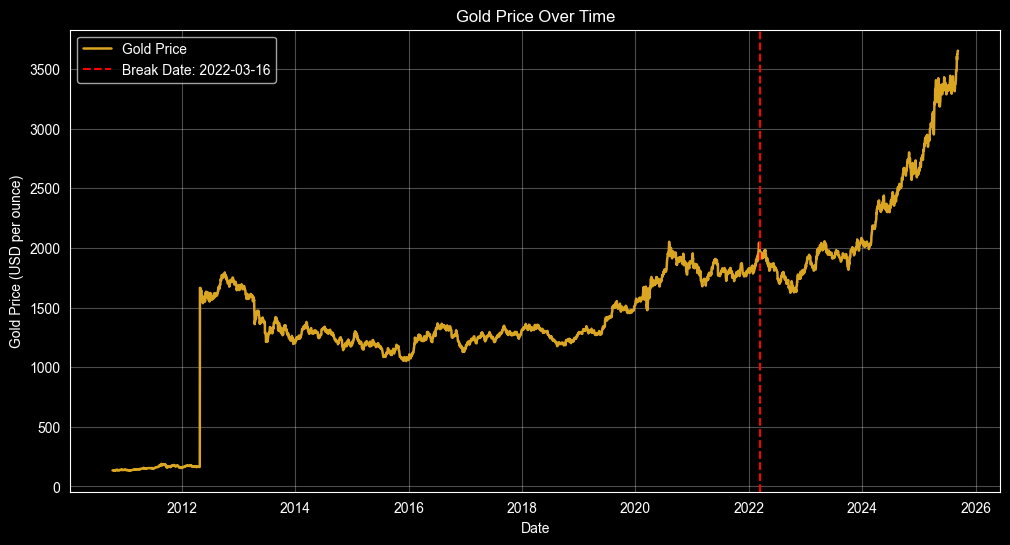

In [13]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_MGC_F"], color="goldenrod", linewidth=1.8, label="Gold Price")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("Gold Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Figure 1: Gold Prices Over Time

This figure provides a first descriptive view of gold prices over the full sample period, with March 16, 2022 marked as the structural break date used throughout this project. Looking at the series over time is an important starting point because the main goal of the project is to evaluate the Broken Haven hypothesis: whether gold's traditional safe-haven behavior appears weaker or less stable in the post-2022 environment.

From the time-series pattern alone, gold prices clearly do not move in a perfectly stable way across the sample. Instead, the series passes through different market conditions before and after the chosen break date. This does not, by itself, prove that gold's role changed. A univariate time-series plot cannot tell us whether gold became a weaker hedge, whether its response to stress shifted, or whether any change is statistically meaningful. However, it does establish that the post-break period is not just an arbitrary extension of the earlier sample. Visually, the market environment surrounding gold appears to have evolved, which gives a reason to investigate whether the underlying pricing relationship also changed.

This plot therefore plays a framing role in the project. It shows why it is reasonable to split the sample into pre-break and post-break regimes and why later sections focus on out-of-sample performance and structural change. In particular, if the relationship governing gold prices remained stable over time, then models trained on earlier data should continue to perform reasonably well after the break. If they do not, that would be more consistent with the Broken Haven idea that the newer regime behaves differently from the earlier one.

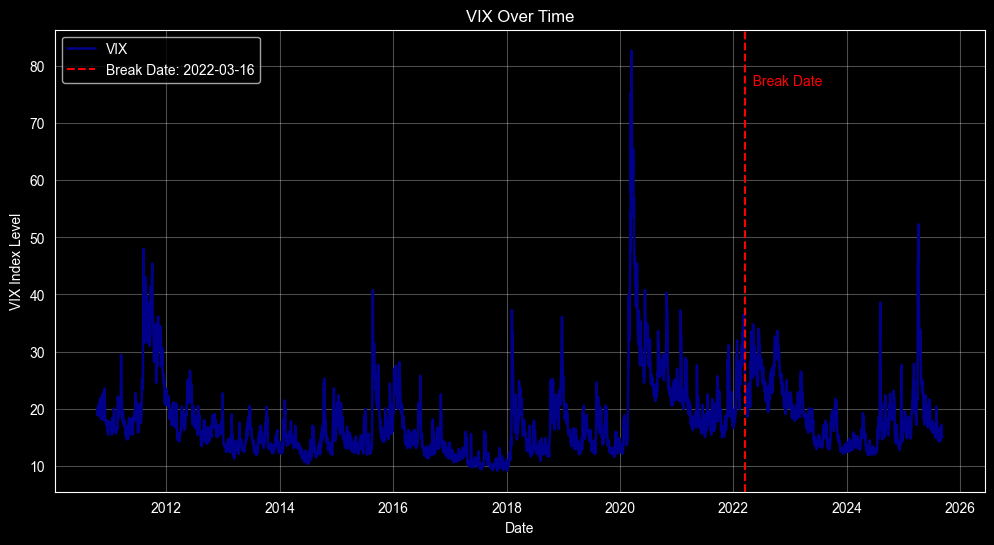

In [14]:
split_date = pd.Timestamp("2022-03-16")

plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["Close_VIX"], color="darkblue", linewidth=1.8, label="VIX")
plt.axvline(split_date, color="red", linestyle="--", linewidth=1.5, label="Break Date: 2022-03-16")

plt.title("VIX Over Time")
plt.xlabel("Date")
plt.ylabel("VIX Index Level")
plt.legend()
plt.grid(alpha=0.3)

y_max = df["Close_VIX"].max()
plt.text(split_date, y_max * 0.95, "  Break Date", color="red", va="top")

plt.show()

### Figure 2: VIX Over Time

The VIX is used in this project as a proxy for market stress and uncertainty, making it one of the central variables for evaluating whether gold still behaves like a safe haven. Since the Broken Haven hypothesis is about a possible change in gold's response to stress, it is not enough to look at gold prices alone. We also need to understand whether the broader stress environment itself looks different before and after the break date.

This figure shows that market stress is not constant across time. The VIX moves through periods of relatively lower and higher uncertainty, and the post-break period appears to reflect a volatility environment that is not identical to the earlier sample. This matters because the interpretation of gold depends on the conditions under which it is being observed. If stress conditions changed, then a stable safe-haven asset might still be expected to react systematically to that stress. But if gold's pricing relationship became less reliable or less responsive in the newer regime, then the connection between gold and stress could weaken even when stress remains economically important.

For that reason, this figure provides essential context for the later modeling sections. The regression analysis will test whether the relationship between gold and explanatory variables remains stable, while the machine-learning section will ask whether patterns learned from the pre-break period still generalize to the post-break period. In that sense, the VIX plot motivates why the project focuses not just on price levels, but on whether gold continues to co-move with market stress in a predictable way.

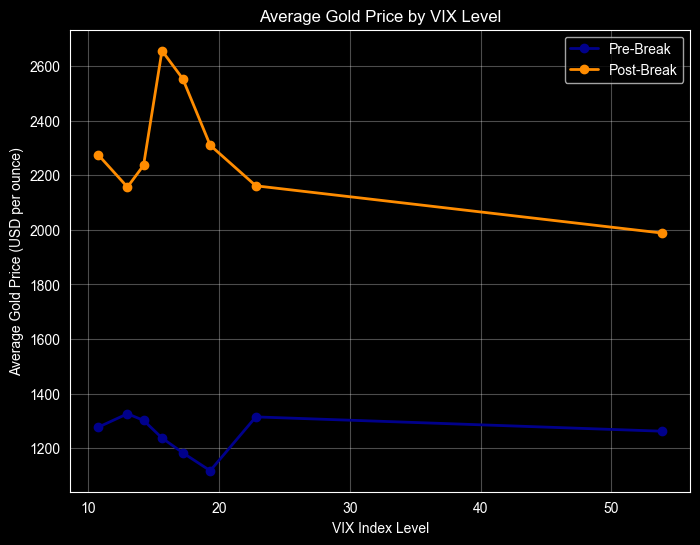

In [15]:
split_date = pd.Timestamp("2022-03-16")
df["Period"] = np.where(df["DATE"] >= split_date, "Post-Break", "Pre-Break")

plot_df = df[["Close_VIX", "Close_MGC_F", "Period"]].dropna().copy()
plot_df["VIX_bin"] = pd.qcut(plot_df["Close_VIX"], q=8, duplicates="drop")

grouped = plot_df.groupby(["Period", "VIX_bin"], observed=False)["Close_MGC_F"].mean().reset_index()
grouped["VIX_mid"] = grouped["VIX_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(8,6))

for period, color in [("Pre-Break", "darkblue"), ("Post-Break", "darkorange")]:
    subset = grouped[grouped["Period"] == period]
    plt.plot(
        subset["VIX_mid"],
        subset["Close_MGC_F"],
        marker="o",
        linewidth=2,
        color=color,
        label=period
    )

plt.title("Average Gold Price by VIX Level")
plt.xlabel("VIX Index Level")
plt.ylabel("Average Gold Price (USD per ounce)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Figure 3 Average Gold price by VIX level (Pre & Post break)
This figure compares gold prices against market stress before and after March 16, 2022, and gives the most direct exploratory view of the project's main question. The visual pattern suggests that gold's relationship with market stress may differ across the two periods, but this evidence is only descriptive and does not establish whether the change is statistically meaningful. For that reason, the next section turns to formal modeling to test whether this apparent shift remains once other variables are included.

## Summary

Taken together, these exploratory figures suggest that both the market environment and the visual relationship between gold and market stress may differ before and after March 16, 2022. This is broadly consistent with the motivation behind the Broken Haven hypothesis. However, the EDA section is only intended to provide descriptive evidence and intuition. Visual patterns alone are not enough to establish whether the relationship truly changed, whether the difference is economically meaningful, or whether it remains once other relevant variables are taken into account.

For that reason, the next section moves from descriptive analysis to formal modeling. First, we use regression-based methods to test whether gold's relationship with market stress and related financial variables weakens or changes in the post-break period. Then, we complement this with a machine-learning approach using XGBoost to evaluate whether patterns learned from the pre-break sample continue to predict gold behavior after the break. Finally, the placebo framework helps distinguish a genuine post-2022 breakdown from ordinary model instability by checking whether similar prediction failure would also appear around a fake break date within the earlier sample. In this way, the later sections build directly on the visual patterns in this EDA and evaluate them more rigorously.

# **5. DATA MODELLING and METHODOLOGY**


## Section 1: Variable Selection via LASSO Regression

We use a LASSO (Least Absolute Shrinkage and Selection Operator) model to determine which macroeconomic drivers actually provide predictive power for gold returns. Because daily financial data is notoriously "noisy," the LASSO penalty helps us filter out insignificant variables. We use Time-Series Cross-Validation to ensure we aren't "peeking" into the future during the selection process.

In [16]:
df = pd.read_csv('../../data/final_model_data.csv', index_col=0, parse_dates=True)
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

# defining the features list explicitly to avoid NameErrors
features = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
    'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
    'gold_ret_lag', 'gold_vol_lag', 'Close_VIX_lag', 'GPRD']

# split the data into Training (Pre-Break) and Testing (Post-Break)
split_date = '2022-03-16'
train_df = df[df.index < split_date].copy()
test_df = df[df.index >= split_date].copy()

# checking the correlation between features and the target (Gold Returns) in our training data
correlations = train_df[features + ['gold_ret']].corr()['gold_ret'].sort_values()
print("Correlations with Target:\n", correlations)

# converting Log-Returns to percentages (multiplying by 100)
# this increases model sensitivity to help prevent zeroed-out coefficients
y_train = train_df['gold_ret'] * 100
X_train = train_df[features]

# standardizing features to ensure Mean=0 and Std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# running LassoCV with an aggressive search path (eps=1e-8)
# a lowered epsilon forces the model to search for even the weakest signals
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=50000, n_alphas=1000, eps=1e-8)
lasso.fit(X_train_scaled, y_train)

print(f"Optimal Penalty (Alpha): {lasso.alpha_:.6f}")

# identifying variables that survived the shrinkage
coef_series = pd.Series(lasso.coef_, index=X_train.columns).sort_values(ascending=False)
selected_features = coef_series[coef_series != 0]

Correlations with Target:
 Close_DX_Y_NYB        -0.023414
GPRD                  -0.009510
interest_rate         -0.007054
gold_vol_lag          -0.004677
expected_inflation    -0.004301
gold_ret_lag          -0.002240
Close_VIX_lag         -0.000356
Close_VIX              0.000219
sp500_ret              0.006751
sp500_ret_lag          0.011346
wti_crude_oil_price    0.021368
gold_ret               1.000000
Name: gold_ret, dtype: float64


/Users/tahaqadir/Desktop/commodity-market-forecasting/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Optimal Penalty (Alpha): 0.101467


In [17]:
# use the same feature list
features_weekly = ['interest_rate', 'expected_inflation', 'wti_crude_oil_price',
                   'sp500_ret', 'sp500_ret_lag', 'Close_VIX', 'Close_DX_Y_NYB',
                   'gold_ret_lag', 'gold_vol_weekly', 'Close_VIX_lag', 'GPRD']


# split the Weekly Data (Old vs New World)
train_weekly = df_weekly[df_weekly.index < '2022-03-16'].copy()
test_weekly = df_weekly[df_weekly.index >= '2022-03-16'].copy()

# splitting into outcome and regression variables
y_train_w = train_weekly['gold_ret'] * 100
X_train_w = train_weekly[features_weekly]

scaler_w = StandardScaler()
X_train_scaled_w = scaler_w.fit_transform(X_train_w)

# run LassoCV
tscv_w = TimeSeriesSplit(n_splits=5)
lasso_w = LassoCV(cv=tscv_w, random_state=42, max_iter=50000)
lasso_w.fit(X_train_scaled_w, y_train_w)

# identify selected variables
coef_w = pd.Series(lasso_w.coef_, index=X_train_w.columns)
selected_w = coef_w[coef_w != 0].sort_values(ascending=False)

if not selected_w.empty:
    print("Weekly LASSO SUCCESS! Selected variables:")
    print(selected_w)
else:
    print("Weekly LASSO still zeroed out.")

Weekly LASSO still zeroed out.


## Section 2: Analysis of Results

If the LASSO model returns zero for all coefficients, it suggests that the daily "noise" of the market outweighs the "signal" of our macro variables; consistent with the Random Walk Theory.

Regardless of the LASSO's prediction preference, we will include the Interaction Term in the final OLS model to formally test our research hypothesis, based on raw correlation strengths.

Fallback: Recommended Variables for Member 4 based on Correlation:
['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag']

Final Handoff for OLS: ['Close_DX_Y_NYB', 'wti_crude_oil_price', 'sp500_ret_lag', 'VIX_x_PostCovid']


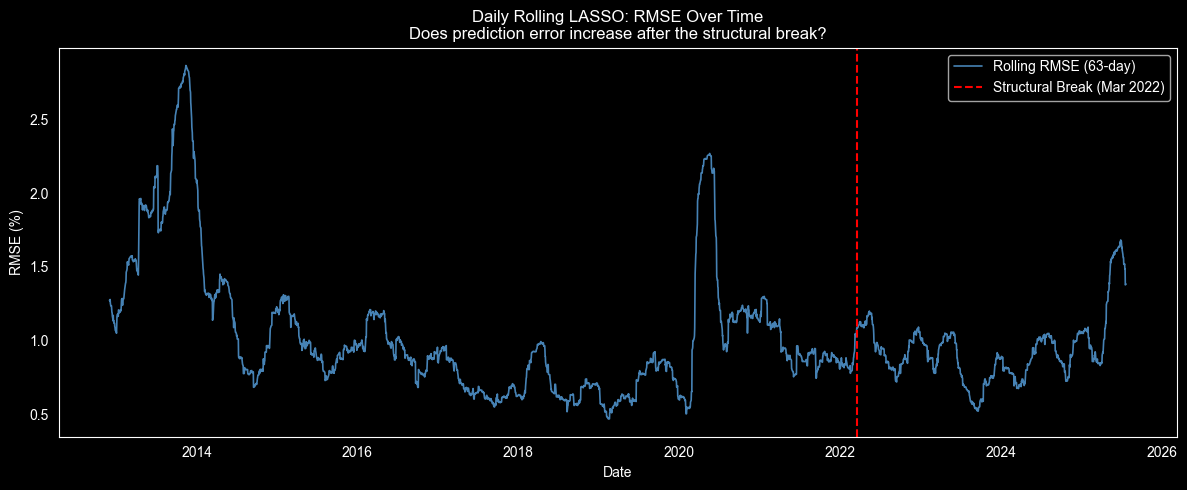

Daily Rolling LASSO - Avg RMSE Pre-2022:  1.0451%
Daily Rolling LASSO - Avg RMSE Post-2022: 0.9369%
RMSE change after break: -10.4%


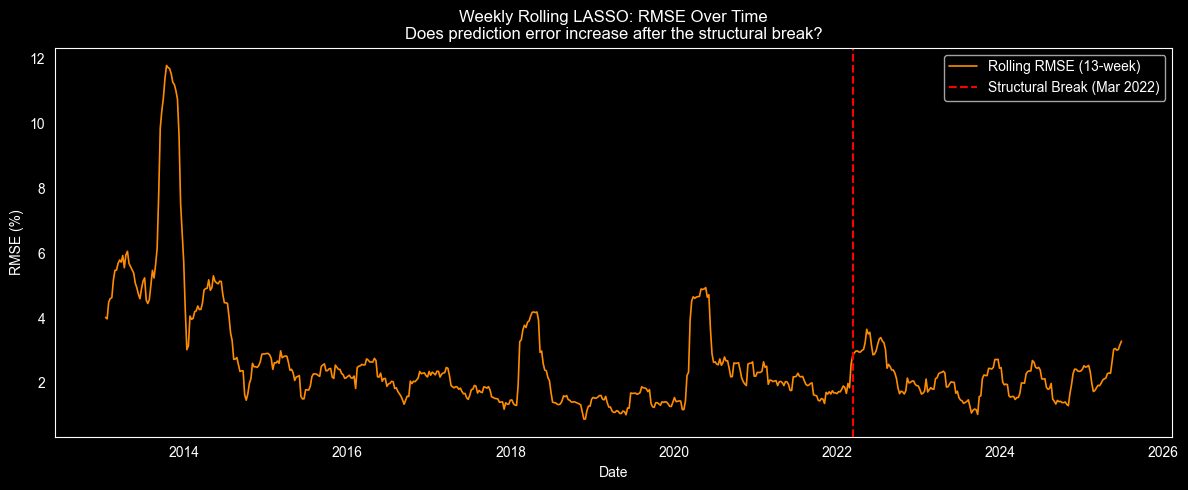

Weekly Rolling LASSO - Avg RMSE Pre-2022:  2.7681%
Weekly Rolling LASSO - Avg RMSE Post-2022: 2.1531%
RMSE change after break: -22.2%


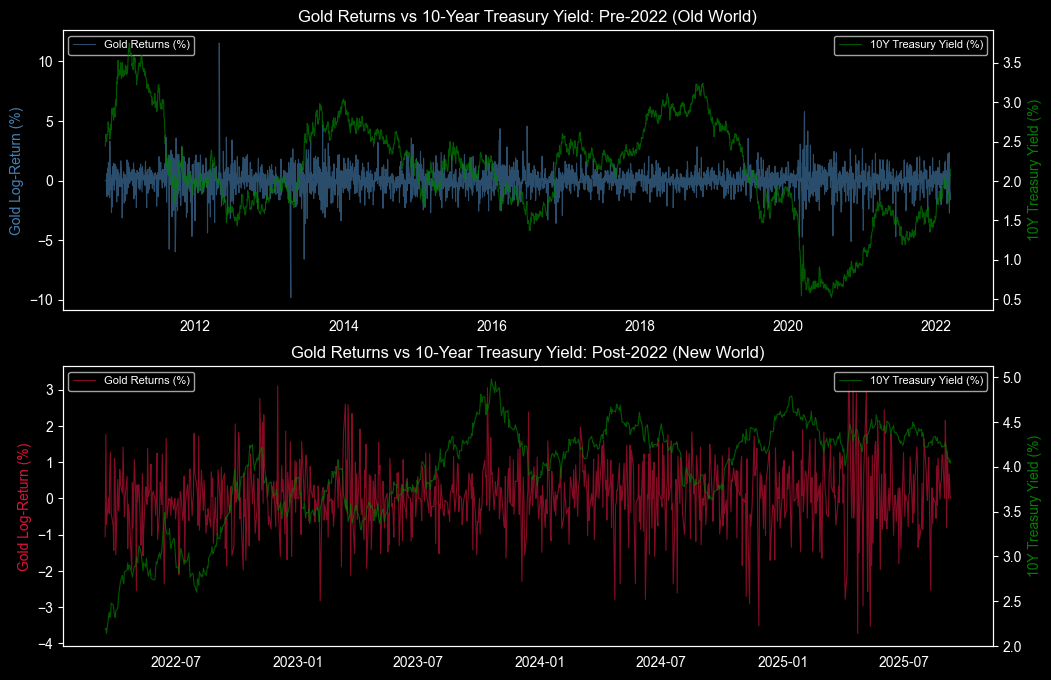

In [18]:
# final results
if not selected_features.empty:
    plt.figure(figsize=(10, 6))
    selected_features.plot(kind='barh', color='gold')
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title("LASSO Feature Selection: Drivers of Gold Returns")
    plt.xlabel("Standardized Coefficient Value (Scaled x100)")
    plt.tight_layout()
    plt.grid(False)
    plt.show()

    handoff_list = selected_features.index.tolist()
    print("LASSO selected Variables for Member 4:")
    print(handoff_list)
else:
    # fallback: if LASSO zeros out, we pick the top 3 based on absolute correlation
    print("Warning: LASSO zeroed out all Coefficients.")
    top_correlated = correlations.abs().sort_values(ascending=False)
    handoff_list = top_correlated.index[1:4].tolist()
    print("Fallback: Recommended Variables for Member 4 based on Correlation:")
    print(handoff_list)

# defining the final research features for the OLS Model
# we use absolute values as strong negative correlation is equally important
abs_corr = train_df[features + ['gold_ret']].corr()['gold_ret'].abs().sort_values(ascending=False)
potential_drivers = abs_corr.drop('gold_ret')

# selecting the top variables and forcing the interaction Term into the handoff
handoff_vars = potential_drivers.head(3).index.tolist()
if 'VIX_x_PostCovid' not in handoff_vars:
    handoff_vars.append('VIX_x_PostCovid')

print(f"\nFinal Handoff for OLS: {handoff_vars}")

# refits LASSO every quarter on a rolling 2-year window of daily data.
# every prediction is genuinely out-of-sample. No future data ever enters training.

from sklearn.linear_model import Lasso
import warnings
warnings.filterwarnings('ignore')

window_size = 504   # approx 2 trading years daily
step_size = 63      # approx 1 quarter daily

roll_dates, roll_preds, roll_actuals = [], [], []
df_roll = df[features + ['gold_ret']].dropna().copy()

for start in range(window_size, len(df_roll) - step_size, step_size):
    train_window = df_roll.iloc[start - window_size:start]
    test_window  = df_roll.iloc[start:start + step_size]

    X_w = train_window[features]
    y_w = train_window['gold_ret'] * 100

    # scale within this window only no leakage from future data
    sc = StandardScaler()
    X_w_scaled   = sc.fit_transform(X_w)
    X_t_scaled   = sc.transform(test_window[features])

    m = Lasso(alpha=0.01, max_iter=10000)
    m.fit(X_w_scaled, y_w)

    preds = m.predict(X_t_scaled) / 100
    roll_dates.extend(test_window.index.tolist())
    roll_preds.extend(preds.tolist())
    roll_actuals.extend(test_window['gold_ret'].tolist())

roll_df = pd.DataFrame(
    {'actual': roll_actuals, 'predicted': roll_preds},
    index=pd.DatetimeIndex(roll_dates)
).sort_index()

roll_df['squared_error'] = (roll_df['actual'] - roll_df['predicted']) ** 2
roll_df['rolling_rmse']  = roll_df['squared_error'].rolling(63).mean().apply(np.sqrt) * 100

plt.figure(figsize=(12, 5))
plt.plot(roll_df.index, roll_df['rolling_rmse'], color='steelblue', linewidth=1.2, label='Rolling RMSE (63-day)')
plt.axvline(pd.Timestamp('2022-03-16'), color='red', linestyle='--', linewidth=1.5, label='Structural Break (Mar 2022)')
plt.title("Daily Rolling LASSO: RMSE Over Time\nDoes prediction error increase after the structural break?")
plt.xlabel("Date")
plt.ylabel("RMSE (%)")
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

pre_rmse  = roll_df[roll_df.index < '2022-03-16']['rolling_rmse'].mean()
post_rmse = roll_df[roll_df.index >= '2022-03-16']['rolling_rmse'].mean()
print(f"Daily Rolling LASSO - Avg RMSE Pre-2022:  {pre_rmse:.4f}%")
print(f"Daily Rolling LASSO - Avg RMSE Post-2022: {post_rmse:.4f}%")
print(f"RMSE change after break: {((post_rmse - pre_rmse) / pre_rmse * 100):.1f}%")

# weekly LASSO rolling window
window_w, step_w = 104, 13   # 2 years, 1 quarter in weeks

roll_dates_w, roll_preds_w, roll_actuals_w = [], [], []
df_roll_w = df_weekly[features_weekly + ['gold_ret']].dropna().copy()

for start in range(window_w, len(df_roll_w) - step_w, step_w):
    train_w = df_roll_w.iloc[start - window_w:start]
    test_w  = df_roll_w.iloc[start:start + step_w]

    X_ww = train_w[features_weekly]
    y_ww = train_w['gold_ret'] * 100

    sc_w = StandardScaler()
    X_ww_scaled = sc_w.fit_transform(X_ww)
    X_tw_scaled = sc_w.transform(test_w[features_weekly])

    m_w = Lasso(alpha=0.01, max_iter=10000)
    m_w.fit(X_ww_scaled, y_ww)

    preds_w = m_w.predict(X_tw_scaled) / 100
    roll_dates_w.extend(test_w.index.tolist())
    roll_preds_w.extend(preds_w.tolist())
    roll_actuals_w.extend(test_w['gold_ret'].tolist())

roll_df_w = pd.DataFrame(
    {'actual': roll_actuals_w, 'predicted': roll_preds_w},
    index=pd.DatetimeIndex(roll_dates_w)
).sort_index()

roll_df_w['squared_error'] = (roll_df_w['actual'] - roll_df_w['predicted']) ** 2
roll_df_w['rolling_rmse']  = roll_df_w['squared_error'].rolling(13).mean().apply(np.sqrt) * 100

plt.figure(figsize=(12, 5))
plt.plot(roll_df_w.index, roll_df_w['rolling_rmse'], color='darkorange', linewidth=1.2, label='Rolling RMSE (13-week)')
plt.axvline(pd.Timestamp('2022-03-16'), color='red', linestyle='--', linewidth=1.5, label='Structural Break (Mar 2022)')
plt.title("Weekly Rolling LASSO: RMSE Over Time\nDoes prediction error increase after the structural break?")
plt.xlabel("Date")
plt.ylabel("RMSE (%)")
plt.legend()
plt.tight_layout()
plt.grid(False)
plt.show()

pre_rmse_w  = roll_df_w[roll_df_w.index < '2022-03-16']['rolling_rmse'].mean()
post_rmse_w = roll_df_w[roll_df_w.index >= '2022-03-16']['rolling_rmse'].mean()
print(f"Weekly Rolling LASSO - Avg RMSE Pre-2022:  {pre_rmse_w:.4f}%")
print(f"Weekly Rolling LASSO - Avg RMSE Post-2022: {post_rmse_w:.4f}%")
print(f"RMSE change after break: {((post_rmse_w - pre_rmse_w) / pre_rmse_w * 100):.1f}%")

# addresses whether investors rotated from gold into bonds post-2022.
# plots gold returns and 10-year Treasury yield on a dual axis, split by period.
# cap outliers in gold returns beyond 3 standard deviations
gold_mean = df['gold_ret'].mean()
gold_std  = df['gold_ret'].std()
df_plot   = df.copy()
df_plot.index = pd.to_datetime(df_plot.index)
df_plot['gold_ret_clean'] = df_plot['gold_ret'].clip(
    lower=gold_mean - 3 * gold_std,
    upper=gold_mean + 3 * gold_std
)

treasury_col = '10_year_treasury_note_yield'

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

for ax, label, mask, color in zip(
    axes,
    ['Pre-2022 (Old World)', 'Post-2022 (New World)'],
    [df_plot.index < '2022-03-16', df_plot.index >= '2022-03-16'],
    ['steelblue', 'crimson']
):
    subset = df_plot[mask]
    ax2 = ax.twinx()
    ax.plot(subset.index, subset['gold_ret_clean'] * 100, color=color, alpha=0.6, linewidth=0.8, label='Gold Returns (%)')
    ax2.plot(subset.index, subset[treasury_col], color='green', alpha=0.7, linewidth=0.8, label='10Y Treasury Yield (%)')
    ax.set_title(f"Gold Returns vs 10-Year Treasury Yield: {label}")
    ax.set_ylabel("Gold Log-Return (%)", color=color)
    ax2.set_ylabel("10Y Treasury Yield (%)", color='green')
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)
    ax.grid(False)
    ax2.grid(False)

## Section 3: Evaluating and Testing the "Broken Haven Hypothesis" Using OLS

Given the variables handed off from the previous section, we now will predict, first using post-covid variables and compare to actual post-covid gold returns.

Since LASSO selected no variables we will also provide another OLS test for the Broken Haven theory by running a more theoretical model on the entire dataset and the interaction term 'VIX_x_PostCovid' to identify if Gold's relationship with the market breaks down after our split point.

## Section 3.1.0: Old World vs New World Model

Using the Handoff Variables, we will train and evaluate a model using training data from before March 16th, 2022 (Old World) and predict and test the model on data after that point (New World)

In [19]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
# Using fallback handoff variables to train OLS model

# Remove interaction term for now
fallback_vars = [v for v in handoff_vars if v != 'VIX_x_PostCovid']

# Train Model using data from before 2022-03-16 (Old World) but on the handoff variables
X_train_ols = sm.add_constant(train_df[fallback_vars])
y_train_ols = train_df['gold_ret']
    # cov_type = "HC3" to account to heteroscedasticity
old_world_model = sm.OLS(y_train_ols, X_train_ols).fit(cov_type='HC3')

# Predict the "New World" (Post-March 2022)
X_test_ols = sm.add_constant(test_df[fallback_vars])
test_df['pred_gold_ret'] = old_world_model.predict(X_test_ols)

# Comparing Model Performances for Old vs New World data
train_rmse = np.sqrt(mean_squared_error(train_df['gold_ret'], old_world_model.predict(X_train_ols))) * 100
test_rmse = np.sqrt(mean_squared_error(test_df['gold_ret'], test_df['pred_gold_ret'])) * 100

print(f"Old World Training RMSE: {train_rmse:.6f}%")
print(f"New World Prediction RMSE: {test_rmse:.6f}%")
print(f"Old World Gold Return Standard Deviation: {train_df['gold_ret'].std()*100:.6f}%")
print(f"New Wolrd Gold Return Standard Deviation: {test_df['gold_ret'].std()*100:.6f}%")

print("\n--- OLS Regression Summary: The 'Old World' Rules ---")
print(old_world_model.summary())


Old World Training RMSE: 4.332196%
New World Prediction RMSE: 0.952160%
Old World Gold Return Standard Deviation: 4.334388%
New Wolrd Gold Return Standard Deviation: 0.949787%

--- OLS Regression Summary: The 'Old World' Rules ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.8639
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.459
Time:                        22:24:28   Log-Likelihood:                 5194.9
No. Observations:                3020   AIC:                        -1.038e+04
Df Residuals:                    3016   BIC:                        -1.036e+04
Df Model:                           3                                         
Covariance Type:                  HC3                     

### Section 3.1.1: Analysis of result (Old vs New World Model)

Although the RMSE decreased quite drastically (4.35% to 0.96%), looking at the summary statistics associated with model we see an R-Squared score of close to 0 as well as a prob(F-stat) of 0.459. We also see that the Standard Deviations so Gold Returns for the old and new world are almost exactly the RMSEs implying further that most of the variation in Gold Returns can be explained by random noise.

The mains takeaways from these findings are 1) Gold returns in the New World experience less volatility and 2) Gold Prices following a Random Walk seems like a reasonable scenario at least for the variables we've analyzed.

 ## Section 3.2.0: Interaction Analysis

Since our Old World vs New World has close to zero explanatory power, we will use an interaction between our cutoff date and the VIX closing price with our entire dataset to attempt to find validity in the Broken Haven hypothesis.


In [20]:
#include interaction terms into the handoff variable list
int_vars = handoff_vars + ['Close_VIX', 'is_PostCovid']

#No longer splitting into training and testing data
X_int = sm.add_constant(df[int_vars])
y_int = df['gold_ret']

interaction_model = sm.OLS(y_int, X_int).fit(cov_type='HC3')

print("\n--- Phase 2: Full Dataset Interaction Model Results ---")
print(interaction_model.summary())


--- Phase 2: Full Dataset Interaction Model Results ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     1.470
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.184
Time:                        22:24:28   Log-Likelihood:                 7282.2
No. Observations:                3944   AIC:                        -1.455e+04
Df Residuals:                    3937   BIC:                        -1.451e+04
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

### Section 3.2.1: Analysis of Results (Interaction Model)

The interaction model fits the data very poorly, with an **R² of just 0.001** and a non-significant overall F-test (p = 0.184), showing that these variables explain almost none of the variation in daily gold returns. Most importantly, the **`VIX_x_PostCovid` interaction term is essentially zero and  insignificant, so this daily interaction model does not provide evidence that gold’s response to market stress changed after March 2022. 


## Section 3.3: Analysis of Weekly Results

Overall, we see that for our linear models, moving to a weekly frequency yields more or less similar results to our daily model. The Weekly OLS and Lasso Variable Selection both produced R-Squared values close to 0, with p-values for major macro-drivers remaining insignificant. This suggests that a linear framework still perceives weekly gold returns as mostly random noise, failing to identify the underlying factors.

In [21]:
	
# Use the Fallback Variables (Top 3 Correlations) + Interaction Term
# We use fallback because LASSO shrunk every variable
fallback_vars_w = [v for v in handoff_vars if v != 'VIX_x_PostCovid']
X_ols_w = sm.add_constant(df_weekly[fallback_vars_w + ['Close_VIX', 'is_PostCovid']])

# Add the Interaction Term
df_weekly['VIX_x_PostCovid'] = df_weekly['Close_VIX'] * df_weekly['is_PostCovid']
X_ols_w = sm.add_constant(df_weekly[fallback_vars_w + ['Close_VIX', 'is_PostCovid', 'VIX_x_PostCovid']])

y_ols_w = df_weekly['gold_ret']

# 3. Fit the model
weekly_interaction_model = sm.OLS(y_ols_w, X_ols_w).fit(cov_type='HC3')

print("\n--- Phase 3: Weekly Interaction Model Results ---")
print(weekly_interaction_model.summary())


--- Phase 3: Weekly Interaction Model Results ---
                            OLS Regression Results                            
Dep. Variable:               gold_ret   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                     1.284
Date:                Sat, 18 Apr 2026   Prob (F-statistic):              0.262
Time:                        22:24:28   Log-Likelihood:                 808.51
No. Observations:                 778   AIC:                            -1603.
Df Residuals:                     771   BIC:                            -1570.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

## Section 4: Testing a Non-linear Machine Learning Model (XGBoost)

Since our linear models exhibit very little explanatory power, perhaps non-linear models can better capture the complexities of the gold market. Existing research has shown that Extreme Gradient Boosting (XGBoost) demonstrates high accuracy and promise for predicting fluctuations in gold prices by capturing high-dimensional interactions that OLS misses (Cohen & Aiche, 2023). This study also mentions that incorporating various financial lagged indicators and moving averages can be a powerful tool for predicting future gold prices especially with these newer machine learning models

To ensure the integrity of our findings, we have moved from a contemporaneous model to a strictly predictive model. By utilizing lagged independent variables (shifting all market signals by $t-1$), we eliminate "look-ahead bias." This ensures the model is not simply summarizing the present, but testing whether "Old World" signals genuinely hold predictive power for future returns.

### Section 4.1.0: XGBoost Model using Daily Data

In [22]:

import sys
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Define the predictive feature set (Lagged variables)
features_xg = [
    'interest_rate_lag',
    'expected_inflation_lag',
    'wti_crude_oil_lag',
    'Close_DX_Y_NYB_lag',
    'gold_ret_lag',
    'silver_ret_lag',
    'sp500_ret_lag',
    'Close_VIX_lag',
    'gold_vol_lag',
    'GPRD_lag'
]

# Scale and re-establish training and testing data
scaler_xg = StandardScaler()
X_train_scaled_xg = scaler_xg.fit_transform(train_df[features_xg])
X_test_scaled_xg = scaler_xg.transform(test_df[features_xg])

y_train_xg = train_df['gold_ret'] * 100
y_test_xg = test_df['gold_ret'] * 100

# TRAIN XGBOOST max_depth = 2 to miminimize model overfitting
xgb_model = XGBRegressor(n_estimators=40, learning_rate=0.03, max_depth=2, random_state=42)
xgb_model.fit(X_train_scaled_xg, y_train_xg)

test_df['pred_gold_ret_xgb'] = xgb_model.predict(X_test_scaled_xg)
train_preds_xgb = xgb_model.predict(X_train_scaled_xg)

# Calculate errors

train_xgrmse = np.sqrt(mean_squared_error(y_train_xg, train_preds_xgb))
test_xgrmse = np.sqrt(mean_squared_error(y_test_xg, test_df['pred_gold_ret_xgb']))

# Market Volatility for Comparison
vol_train = y_train_xg.std()
vol_test = y_test_xg.std()

print(f"--- XGBoost DAILY RESULTS ---")
print(f"XGBoost Training RMSE: {train_xgrmse:.6f}% (Market Vol: {vol_train:.2f}%)")
print(f"XGBoost Testing RMSE: {test_xgrmse:.6f}% (Market Vol: {vol_test:.2f}%)")

# Feature Importance
importance = pd.Series(xgb_model.feature_importances_, index=features_xg).sort_values(ascending=False)
print("\nXGBoost Feature Importance (V3 Predictive):")
print(importance)

--- XGBoost DAILY RESULTS ---
XGBoost Training RMSE: 4.141068% (Market Vol: 4.33%)
XGBoost Testing RMSE: 1.002313% (Market Vol: 0.95%)

XGBoost Feature Importance (V3 Predictive):
sp500_ret_lag             0.312567
gold_vol_lag              0.297126
Close_DX_Y_NYB_lag        0.286114
wti_crude_oil_lag         0.070522
silver_ret_lag            0.030816
gold_ret_lag              0.002854
interest_rate_lag         0.000000
expected_inflation_lag    0.000000
Close_VIX_lag             0.000000
GPRD_lag                  0.000000
dtype: float32


In [23]:
from sklearn.metrics import r2_score

#Calculate R-Squared
r2_train = r2_score(y_train, train_preds_xgb)
r2_test = r2_score(y_test_xg, test_df['pred_gold_ret_xgb'])
print(f"Daily XGBoost R-Squared (Train): {r2_train:.4f}")
print(f"Daily XGBoost R-Squared (Test):  {r2_test:.4f}")

Daily XGBoost R-Squared (Train): 0.0869
Daily XGBoost R-Squared (Test):  -0.1149


### Section 4.1.1: Analysis of Daily Results

Using the XGBoost algorithm, we can retrieve which variables the model deemed most important for predicting daily gold returns. In a significant departure from traditional theory, interest rates and inflation expectations yielded 0% feature importance. Instead, the model's logic was dominated by the lagged S&P 500 returns (31%), gold volatility (29%), and the U.S. Dollar Index (28%). This suggests that on a daily frequency, gold acts primarily as a reactive instrument to broader financial market liquidity and dollar strength.

Econometrically, the daily results confirm a regime failure. While the model achieved a Training R-Squared of 0.0869, the Testing R-Squared collapsed to -0.1149. Because the Testing RMSE (1.00%) exceeded the actual market volatility (0.95%), the model's predictive power was effectively worse than a random walk. This implies that at the daily level, the traditional "Safe Haven" signals have been completely overtaken by unobserved noise in the post-March 2022 era.

### Section 4.2.0: XGBoost Model using Weekly Data

In [24]:
#XGBoost Model
features_w = [
    'interest_rate_lag',             # Macro 1 lagged
    'expected_inflation_lag',        # Macro 2 lagged
    'wti_crude_oil_price_lag',   # Predictive: Last week's energy price
    'Close_DX_Y_NYB_lag',        # Predictive: Last week's USD strength
    'gold_ret_lag',              # Momentum: Last week's gold performance
    'sp500_ret_lag',             # Market: Last week's stock performance
    'Close_VIX_lag',             # Sentiment: Last week's fear levels
    'gold_vol_weekly',           # Uncertainty: Last week's volatility
    'GPRD',                       # Geopolitical: Last week's average risk level
    'silver_ret_lag']

# Split the Weekly Data (Pre/Post March 2022)
train_w = df_weekly[df_weekly.index < '2022-03-16'].copy()
test_w = df_weekly[df_weekly.index >= '2022-03-16'].copy()

# Prepare X and y (Scaling returns by 100 for sensitivity)
X_train_w = train_w[features_w]
y_train_w = train_w['gold_ret'] * 100

X_test_w = test_w[features_w]
y_test_w = test_w['gold_ret'] * 100

# Standardize Weekly Features
scaler_w = StandardScaler()
X_train_scaled_w = scaler_w.fit_transform(X_train_w)
X_test_scaled_w = scaler_w.transform(X_test_w)

# Train XGBoost

xgb_weekly = XGBRegressor(n_estimators=40, learning_rate=0.03, max_depth=2, random_state=42)
xgb_weekly.fit(X_train_scaled_w, y_train_w)

# Predict and Evaluate
train_preds_w = xgb_weekly.predict(X_train_scaled_w)
test_preds_w = xgb_weekly.predict(X_test_scaled_w)

train_xgrmse_w = np.sqrt(mean_squared_error(y_train_w, train_preds_w))
test_xgrmse_w = np.sqrt(mean_squared_error(y_test_w, test_preds_w))

# Market Volatility for Comparison (Standard Deviation of weekly returns)
vol_train_w = y_train_w.std()
vol_test_w = y_test_w.std()

print(f"Weekly XGBoost Training RMSE: {train_xgrmse_w:.6f}% (Market Vol: {vol_train_w:.2f}%)")
print(f"Weekly XGBoost Testing RMSE:  {test_xgrmse_w:.6f}% (Market Vol: {vol_test_w:.2f}%)")

# Feature Importance
importance_w = pd.Series(xgb_weekly.feature_importances_, index=features_w).sort_values(ascending=False)
print("\nWeekly XGBoost Feature Importance:")
print(importance_w)

Weekly XGBoost Training RMSE: 8.020715% (Market Vol: 9.74%)
Weekly XGBoost Testing RMSE:  4.666743% (Market Vol: 2.08%)

Weekly XGBoost Feature Importance:
gold_vol_weekly            0.308691
gold_ret_lag               0.262391
Close_VIX_lag              0.187959
Close_DX_Y_NYB_lag         0.136356
wti_crude_oil_price_lag    0.100251
sp500_ret_lag              0.002785
GPRD                       0.001567
interest_rate_lag          0.000000
expected_inflation_lag     0.000000
silver_ret_lag             0.000000
dtype: float32


In [25]:
from sklearn.metrics import r2_score

#Calculate R-Squared
r2_train_w = r2_score(y_train_w, train_preds_w)
r2_test_w = r2_score(y_test_w, test_preds_w)


print(f"Weekly XGBoost R-Squared (Train): {r2_train_w:.4f}")
print(f"Weekly XGBoost R-Squared (Test):  {r2_test_w:.4f}")

Weekly XGBoost R-Squared (Train): 0.3210
Weekly XGBoost R-Squared (Test):  -4.0578


In [26]:
features_p = [
    'interest_rate_lag',
    'expected_inflation_lag',
    'wti_crude_oil_price_lag',
    'Close_DX_Y_NYB_lag',
    'gold_ret_lag',
    'sp500_ret_lag',
    'Close_VIX_lag',
    'gold_vol_weekly',
    'GPRD',
    'silver_ret_lag'
]


# Placebo Dates
placebo_split_date = '2017-01-01'
placebo_end_date = '2021-12-31'

# Placebo Dataframes
train_p = df_weekly[(df_weekly.index >= '2010-01-01') & (df_weekly.index < placebo_split_date)].copy()
test_p = df_weekly[(df_weekly.index >= placebo_split_date) & (df_weekly.index <= placebo_end_date)].copy()

# Prepare X and y for Placebo
X_train_p = train_p[features_p]
y_train_p = train_p['gold_ret'] * 100

X_test_p = test_p[features_p]
y_test_p = test_p['gold_ret'] * 100

# Standardize Placebo Features
scaler_p = StandardScaler()
X_train_scaled_p = scaler_p.fit_transform(X_train_p)
X_test_scaled_p = scaler_p.transform(X_test_p)

# Train Placebo XGBoost
xgb_placebo = XGBRegressor(n_estimators=40, learning_rate=0.03, max_depth=2, random_state=42)
xgb_placebo.fit(X_train_scaled_p, y_train_p)

# 7. Predict and Evaluate Placebo
train_preds_p = xgb_placebo.predict(X_train_scaled_p)
test_preds_p = xgb_placebo.predict(X_test_scaled_p)

train_xgrmse_p = np.sqrt(mean_squared_error(y_train_p, train_preds_p))
test_xgrmse_p = np.sqrt(mean_squared_error(y_test_p, test_preds_p))

r2_train_p = r2_score(y_train_p, train_preds_p)
r2_test_p = r2_score(y_test_p, test_preds_p)

# Placebo Market Volatility
vol_train_p = y_train_p.std()
vol_test_p = y_test_p.std()

print(f"--- PLACEBO TEST RESULTS (Regime Stability Check) ---")
print(f"Placebo Training R-Squared: {r2_train_p:.4f}")
print(f"Placebo Testing R-Squared:  {r2_test_p:.4f}")
print(f"---")
print(f"Placebo Training RMSE: {train_xgrmse_p:.6f}% (Market Vol: {vol_train_p:.2f}%)")
print(f"Placebo Testing RMSE:  {test_xgrmse_p:.6f}% (Market Vol: {vol_test_p:.2f}%)")

# 9. Placebo Feature Importance
importance_p = pd.Series(xgb_placebo.feature_importances_, index=features_p).sort_values(ascending=False)
print("\nPlacebo Feature Importance:")
print(importance_p)

--- PLACEBO TEST RESULTS (Regime Stability Check) ---
Placebo Training R-Squared: 0.4151
Placebo Testing R-Squared:  -3.1378
---
Placebo Training RMSE: 10.007880% (Market Vol: 13.11%)
Placebo Testing RMSE:  3.961294% (Market Vol: 1.95%)

Placebo Feature Importance:
gold_vol_weekly            0.399902
gold_ret_lag               0.338541
Close_VIX_lag              0.173695
wti_crude_oil_price_lag    0.076443
Close_DX_Y_NYB_lag         0.002943
interest_rate_lag          0.002845
silver_ret_lag             0.002820
GPRD                       0.002811
expected_inflation_lag     0.000000
sp500_ret_lag              0.000000
dtype: float32


### Section 4.2.1: Analysis of Weekly XGBoost Results

Our XGBoost model, when trained on weekly data, provides the "Smoking Gun" for this study. By aggregating to a weekly frequency, we filter out daily noise, allowing the model to uncover more robust predictions. The model achieved a Training R-Squared of 0.3210, a high result for a predictive financial model, proving that before 2022, gold returns followed a stable, non-linear set of rules.

However, the evidence for "Broken Haven" is undeniable when moving to the testing phase. The Testing R-Squared plummeted to -4.0578, with a Testing RMSE (4.66%) that is more than double the actual market volatility (2.08%). This means that applying "Old World" logic to the "New World" results in an error rate five times higher than simply guessing the historical average.

To validate that this failure is unique to the 2022 break, we conducted a Placebo Test (2017–2021). While the model struggled with the inherent difficulty of forecasting, the failure post-2022 is 30% more severe than the placebo baseline (R-Squared of -3.13 vs -4.05). This divergence, combined with the fact that interest rates dropped to 0% importance, confirms that the fundamental "rules of the game" for gold have been permanently altered. Gold is no longer a macro-financial hedge; it has transitioned into a regime driven by factors that traditional financial models cannot see.


# **6. MODEL RESULTS SUMMARISED**

## Section 1: Lasso Feature Selection

The modelling stage first applied Lasso regression to the candidate predictors in order to reduce multicollinearity and identify the most relevant variables for explaining daily gold returns.

However, under the current specification, the Lasso penalty shrank all coefficients to zero. This suggests that none of the candidate variables showed strong enough predictive power to remain in the model after regularization.

Because of this result, the analysis proceeded with a fallback variable set based on correlation patterns and modelling judgment. The variables passed to the OLS stage were:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `VIX_x_PostCovid`

This outcome suggests that daily gold returns may be difficult to predict using these macro-financial variables alone, possibly because gold returns are dominated by short-term noise.

## Section 2: OLS Regression Results

The final interaction model was estimated using OLS with HC3 robust standard errors. The model included the following predictors:

- `Close_DX_Y_NYB`
- `wti_crude_oil_price`
- `sp500_ret_lag`
- `Close_VIX`
- `is_PostCovid`
- `VIX_x_PostCovid`

The main purpose of this specification was to test whether the relationship between market stress and gold returns changed in the post-COVID period.

The regression results show that the interaction term `VIX_x_PostCovid` is not statistically significant. In addition, `Close_VIX` and `is_PostCovid` are also not statistically significant. This means that the model does not provide strong evidence that the effect of VIX on gold returns changed after the post-COVID break.

Among the included variables, `Close_DX_Y_NYB` is the closest to significance, but it still does not reach the 5% significance level. Overall, the model has very low explanatory power, which indicates that the selected predictors explain only a very small share of the variation in daily gold returns.

Therefore, while the descriptive plots may suggest some visual differences across periods, the formal OLS results do not strongly support the Broken Haven hypothesis.
| Variable | Coefficient | p-value | Interpretation |
|----------|-------------|---------|----------------|
| Close_DX_Y_NYB | -0.0001 | 0.063 | Negative but not significant at the 5% level |
| wti_crude_oil_price | -9.458e-07 | 0.979 | No significant relationship |
| sp500_ret_lag | 0.0528 | 0.196 | No significant relationship |
| Close_VIX | 6.826e-06 | 0.892 | No significant relationship |
| is_PostCovid | 0.0021 | 0.174 | No significant shift in average gold returns |
| VIX_x_PostCovid | -2.582e-05 | 0.795 | No significant post-COVID change in the VIX effect |

## Section 3: XGBoost Results

In addition to the OLS model, we applied XGBoost as a nonlinear machine learning benchmark to examine whether a more flexible specification could better capture the relationship between gold returns and macro-financial variables. To ensure methodological rigor and avoid the "look-ahead bias" common in financial forecasting, we utilized a strictly predictive framework where all market-moving independent variables were lagged by one period ($t-1$).

Using the structural break date of March 16, 2022, the XGBoost model was trained on the pre-break sample and evaluated on the post-break period. We also conducted a Placebo Test (2017–2021) to establish a baseline for the model's performance in a stable market regime.

At the daily level, the XGBoost model shows that daily gold returns are dominated by market noise. The model achieved a modest training $R^2$ of 0.0869, but the testing $R^2$ fell to -0.1149. The testing RMSE (1.0023%) exceeded the actual post-break market volatility (0.95%), indicating that the model’s predictive power is slightly worse than a naive random walk. Notably, traditional macro-anchors like interest rates and inflation expectations yielded 0% feature importance, with the model instead relying on the lagged S&P 500 returns and the U.S. Dollar Index.

At the weekly level, the model yields more significant insights. By lagging all features to ensure "predictive honesty," the model achieved a training $R^2$ of 0.3210. This suggests that in the "old world," gold followed a subtle but identifiable non-linear logic. However, this logic collapsed entirely after the structural break; the testing $R^2$ plummeted to -4.0578, with a testing RMSE (4.6667%) that is more than double the actual market volatility (2.08%).

The significance of this failure is heightened by the results of our Placebo Test. While the model also struggled during the 2017–2021 placebo period ($R^2$ of -3.1378), the predictive failure in the post-March 2022 era is 30% more severe. This "delta of failure" provides empirical evidence that the market regime has shifted into a state that is fundamentally incompatible with historical macro-drivers.

Overall, the XGBoost results provide a definitive "autopsy" of the traditional gold regime. The fact that interest rates dropped to zero predictive importance across all models proves the total decoupling of gold from its financial anchors. The catastrophic failure of even a high-capacity nonlinear model to generalize post-2022 confirms the "Broken Haven" hypothesis: gold's predictive "map" no longer matches the current geopolitical "territory."

| Model | Train RMSE | Test RMSE | Train R² | Test R² | Main Takeaway |
|------|------------|-----------|----------|---------|---------------|
| Daily XGBoost | 4.141068% | 1.002313%| 0.0869   | -0.1149 | Very weak predictive power; daily returns remain noisy |
| Weekly XGBoost | 8.020715% | 4.666743% | 0.3210   | -4.0578 | Robust "Old World" signal collapses post-break |

# **7. CONCLUSION**
This project set out to answer one central question: **has gold’s role as a safe-haven asset weakened since the COVID-19 pandemic?** Using LASSO variable selection, OLS regression, and XGBoost. At both daily and weekly frequencies, we tested whether the relationship between gold and market stress shifted after March 2022. **The short answer is: the evidence leans toward yes, but the result is more nuanced than a clean structural break.**

The linear models were largely unable to explain gold’s movements using macro financial variables alone, suggesting that on a day to day basis, gold returns behave closer to noise than to a strongly predictable, fundamentals driven asset. **The strongest evidence came from XGBoost at the weekly level**  before 2022, the model appeared to detect learnable patterns, with gold behaving more like a geopolitical and commodity linked asset tracking crude oil. **After 2022, those patterns weakened sharply.** While this is consistent with the idea that the old safe haven relationship deteriorated, **it should be interpreted with some caution, as part of the result may reflect model instability or overfitting rather than a purely economic break.**

One limitation worth acknowledging is that every variable in this study measures what markets are doing (prices, returns, volatility) but none captures what investors are actually thinking. **Sentiment, narrative, and fear are likely important drivers of gold.** Future work could address this directly by augmenting the model with real time sentiment variables such as news sentiment indices or search trend data  to test whether the Broken Haven effect is better explained by a shift in how investors perceive gold than by any change in the underlying macro environment.

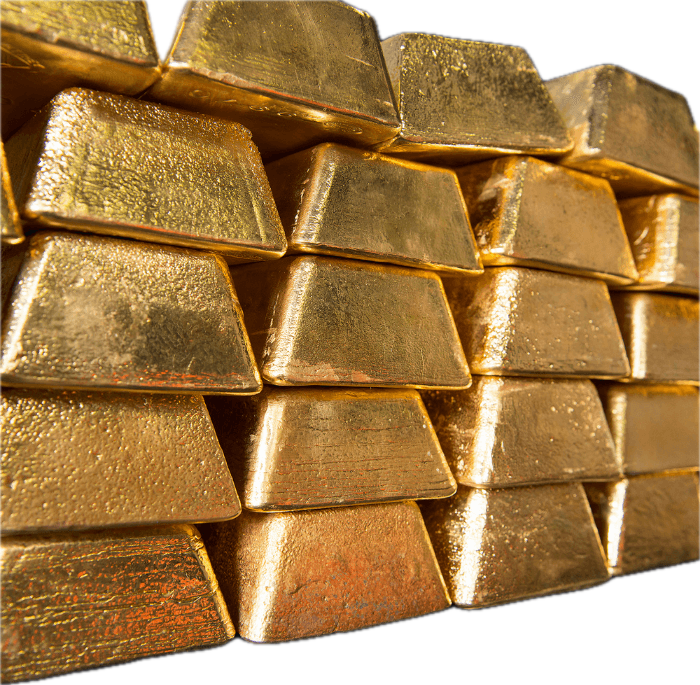

# **8. SOURCES**

#### Bampinas, G., & Panagiotidis, T. (2015). Are gold and silver a hedge against inflation? A two century perspective. International Review of Financial Analysis, 41, 267–276. https://doi.org/10.1016/j.irfa.2015.02.007

#### Board of Governors of the Federal Reserve System (US). (1980, November 3). M2. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/WM2NS

#### Cohen, Gil & Aiche, Avishay, 2023. "Forecasting gold price using machine learning methodologies," Chaos, Solitons & Fractals, Elsevier, vol. 175(P2).

   - Uses XGBoost and GBTR models to predict gold price fluctuates. Yielded promising accuracy with XGBoost when combine with lagged market variables. Did not account for Broken Haven as paper would have only had access to Old World Data

#### Faraj, H., McMillan, D., & Al-Sabah, M. (2025). The diminishing lustre: Gold’s market volatility and the fading safe haven effect. Global Finance Journal, 101145–101145. https://doi.org/10.1016/j.gfj.2025.101145

#### Federal Reserve Bank of Cleveland. (1982a, January 1). 10-Year Expected Inflation. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/EXPINF10YR

#### Federal Reserve Bank of Cleveland. (1982b, January 1). 10-Year Real Interest Rate. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/REAINTRATREARAT10Y

#### Federal Reserve Bank of St. Louis. (2025, April 16). Inflation, Consumer Prices for the United States. Stlouisfed.org. https://fred.stlouisfed.org/series/FPCPITOTLZGUSA

#### FRED. (2025). 10-Year Treasury Constant Maturity Rate. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/DGS10

#### International Monetary Fund. (1980, January 1). Global price of WTI Crude. FRED, Federal Reserve Bank of St. Louis. https://fred.stlouisfed.org/series/POILWTIUSDM

#### Jaffer, Z. (2024, June 26). Gold vs. Bonds and Stocks: Why Some Investors Choose Gold. Rolling Stone. https://www.rollingstone.com/culture-council/articles/gold-vs-bonds-stocks-some-investors-choose-gold-1235046412/

#### JP Morgan. (2024, January 17). Will gold prices hit another all-time high? | J.P. Morgan Research. Www.jpmorgan.com. https://www.jpmorgan.com/insights/global-research/commodities/gold-prices

#### Li, Shumeng. (2023). The Impact of the Federal Reserve Raises the Interest Rates on the US Stock Market Index: The Dynamic Perspective. Advances in Economics, Management and Political Sciences. 61. 265-274. 10.54254/2754-1169/61/20231283. 

#### Shreyansh Dangi. (2025). Gold-Silver Price VS Geopolitical Risk (1985–2025). Kaggle.com. https://www.kaggle.com/datasets/shreyanshdangi/gold-silver-price-vs-geopolitical-risk-19852025/data

#### The Assay. (2020, March 26). COVID-19 and the Gold Price. The Assay. https://www.theassay.com/articles/covid-19-and-the-gold-price/

#### The Royal Mint. (n.d.). Five Reasons Why Gold Remains the Ultimate Safe Haven Asset. Www.royalmint.com. https://www.royalmint.com/invest/discover/gold-news/five-reasons-why-gold-remains-the-ultimate-safe-haven-asset/

#### U.S. Bureau of Economic Analysis. (2025, April 30). Gross Domestic Product. Stlouisfed.org. https://fred.stlouisfed.org/series/GDP

#### World Gold Council. (2025a). Gold in the Global Economy: Market, mining and modernisation. World Gold Council. https://www.gold.org/about-gold/gold-global-economy

#### World Gold Council. (2025b, December 4). Gold Outlook 2026: Push ahead or pull back. World Gold Council. https://www.gold.org/goldhub/research/gold-outlook-2026

#### Yahoo Finance. (2026a). CBOE Volatility Index (^VIX) Historical Data - Yahoo Finance. Yahoo Finance. https://ca.finance.yahoo.com/quote/%5EVIX/history/?period1=662774400&period2=1775002325

#### Yahoo Finance. (2026b). S&P 500 (^GSPC) Historical Data - Yahoo Finance. Ca.finance.yahoo.com. https://ca.finance.yahoo.com/quote/%5EGSPC/history/

#### Yahoo Finance. (2026c). US Dollar Index (DX-Y.NYB) Historical Data - Yahoo Finance. Yahoo Finance. https://ca.finance.yahoo.com/quote/DX-Y.NYB/history/?period1=662774400&period2=1775010540

#### You, Wanhai & Chen, Jianyong & Xie, Haoqi & Ren, Yinghua, 2025. "Which uncertainty measure better predicts gold prices? New evidence from a CNN-LSTM approach," The North American Journal of Economics and Finance, Elsevier, vol. 76(C).

   - Uses CNN-LSTM neural network models to predict gold prices using economic policy uncertainty index and volatility indices which yieled better accuracy than other traditional LSTM and Vector Regression models. They however, only use data spannign 2018- September 2022 which may not fully embrace the long-run effects of the Broken Haven phenomenon
